# Exploratory data analysis

## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import spotipy
from spotipy.oauth2 import SpotifyOAuth
from dotenv import load_dotenv

load_dotenv()

True

## Load clean dataframe

In [2]:
df_music = pd.read_pickle("../data/processed/df_music_clean.pkl")

## Hours per year (add hours played & year)

In [3]:
df_music["hours_played"] = df_music["ms_played"] / 1000 / 60 / 60
df_music["hours_played"].sum()

np.float64(6119.397646944444)

In [4]:
df_music["year"] = df_music["ts"].dt.year
df_music["year"].value_counts().sort_index()

year
2012      798
2013     2129
2014    10142
2015     7219
2016      284
2017     3877
2018     9274
2019     8152
2020    10271
2021    10350
2022    10394
2023    14008
2024    11489
2025    12414
2026     5770
Name: count, dtype: int64

In [5]:
df_music.groupby("year").agg({"hours_played": "sum"}).sort_index()

,hours_played
year,
2012,40.566114
2013,120.077307
2014,560.987427
2015,400.775247
2016,17.017503
2017,206.021735
2018,468.796488
2019,421.811120
2020,550.547111


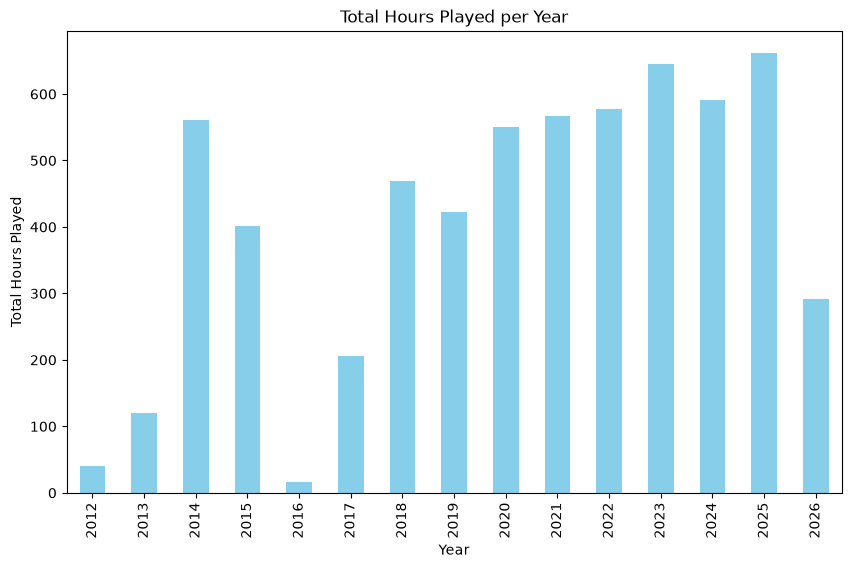

In [6]:
yearly_hours = df_music.groupby("year")["hours_played"].sum()
yearly_hours.plot(kind="bar", figsize=(10, 6), color="skyblue")
plt.title("Total Hours Played per Year")
plt.xlabel("Year")
plt.ylabel("Total Hours Played")
plt.show()

Had no full Spotify Premium account in the years 2012, 2013, 2016, 2017. Therefore significantly fewer plays in these years

## Top songs

In [7]:
top_songs = (
    df_music
    .groupby(
        [
            "master_metadata_track_name",
            "master_metadata_album_artist_name"
        ]
    )
    .agg(
        play_count=("master_metadata_track_name", "count"),
        minutes_played=("minutes_played", "sum")
    )
    .sort_values(by="minutes_played", ascending=False)
    .reset_index()
)

In [8]:
top_songs.head(20)

,master_metadata_track_name,master_metadata_album_artist_name,play_count,minutes_played
0,A View from the Top of the World,Dream Theater,36,476.993067
1,The Message [Tablet III],Blood Incantation,31,329.632750
2,Hell On Earth,Iron Maiden,42,318.362517
3,The Parchment,Iron Maiden,32,287.291550
4,Skyfall,Helloween,32,283.979200
5,The Stargate [Tablet I],Blood Incantation,45,267.652750
6,Deutschland,Rammstein,58,232.698183
7,7empest,TOOL,23,232.546117
8,"Devour Me, Colossus - Part I - Blackholes",Ne Obliviscaris,25,228.013050
9,The Ballad of Frankie Lee and Judas Priest,Bob Dylan,58,226.305033


In [9]:
top20 = top_songs.head(20).copy()

top20["song_label"] = (
    top20["master_metadata_track_name"]
    + " – "
    + top20["master_metadata_album_artist_name"]
)

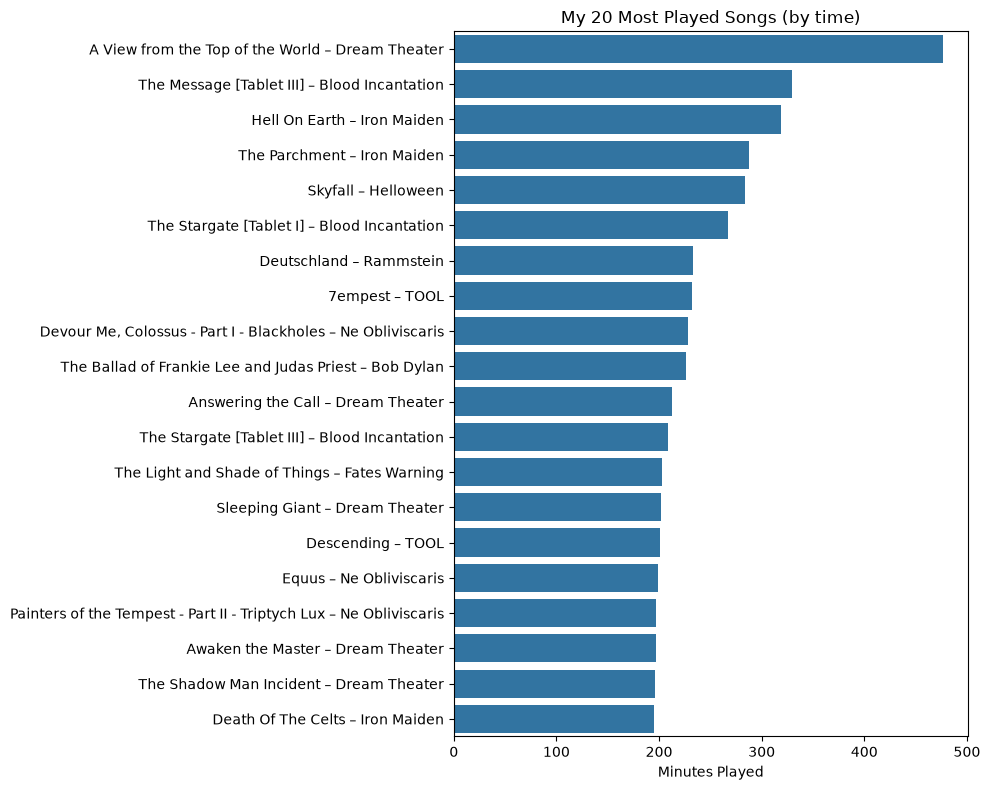

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top20,
    x="minutes_played",
    y="song_label"
)

plt.title("My 20 Most Played Songs (by time)")
plt.xlabel("Minutes Played")
plt.ylabel("")

plt.tight_layout()
plt.show()

Displaying the most played songs by time gives interesting insights, as this is usually not displayed by apps like lastfm. The songs in this list are mostly rather long.

## Top Bands

In [11]:
top_bands = (
    df_music
    .groupby(
        [
            "master_metadata_album_artist_name"
        ]
    )
    .agg(
        play_count=("master_metadata_album_artist_name", "count"),
        hours_played=("hours_played", "sum")
    )
    .sort_values(by="hours_played", ascending=False)
    .reset_index()
)

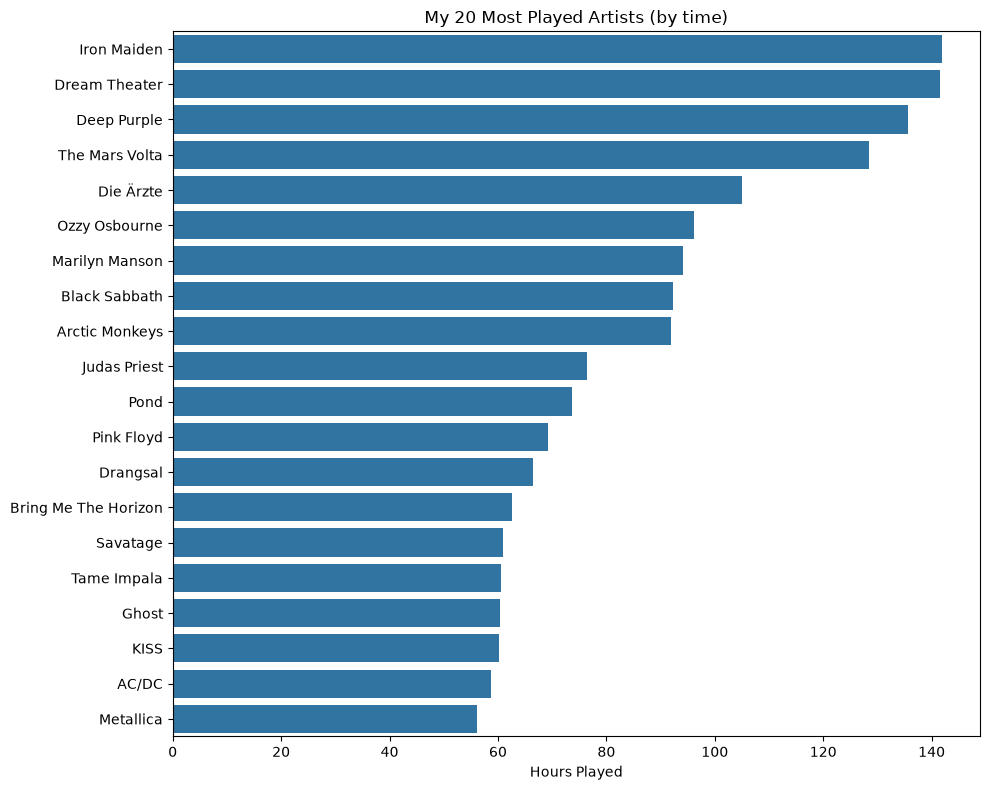

In [12]:
top20_bands = top_bands.head(20).copy()

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top20_bands,
    x="hours_played",
    y="master_metadata_album_artist_name"
)

plt.title("My 20 Most Played Artists (by time)")
plt.xlabel("Hours Played")
plt.ylabel("")

plt.tight_layout()
plt.show()


## Play time per hour of daytime

In [13]:
df_music["hour"] = df_music["ts"].dt.hour
hourly_stats = (
    df_music
    .groupby(
        [
            "hour"
        ]
    )
    .agg(
        play_count=("hour", "count"),
        hours_played=("hours_played", "sum")
    )
    .reset_index()
)

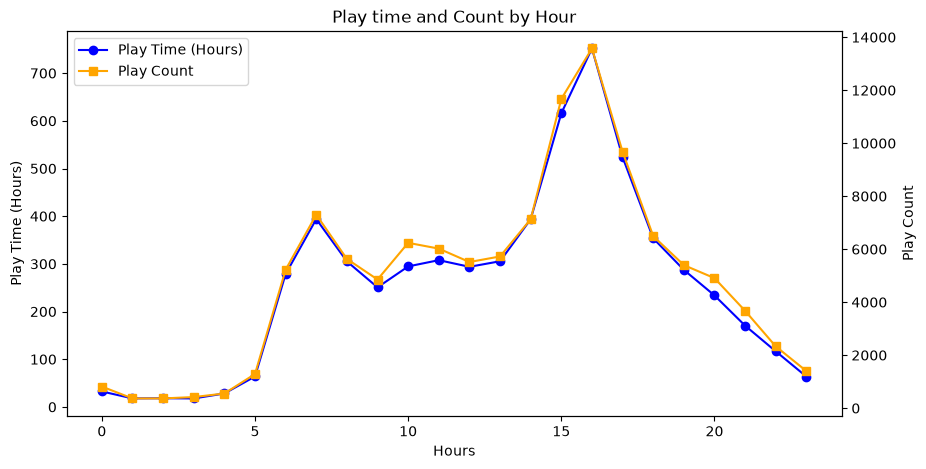

In [14]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Linke y-Achse
line1, = ax1.plot(hourly_stats["hour"], hourly_stats["hours_played"], marker="o", color="blue")
ax1.set_xlabel("Hours")
ax1.set_ylabel("Play Time (Hours)")

# Rechte y-Achse
ax2 = ax1.twinx()
line2, = ax2.plot(hourly_stats["hour"], hourly_stats["play_count"], marker="s", color="orange")
ax2.set_ylabel("Play Count")

plt.title("Play time and Count by Hour")
plt.legend([line1, line2], ["Play Time (Hours)", "Play Count"], loc="upper left")
plt.show()

## Top artists per year

In [15]:
# Top 20 Künstler insgesamt
top_artists = (
    df_music["master_metadata_album_artist_name"]
    .value_counts()
    .head(20)
    .index
)

# Nur diese Künstler behalten
heatmap_data = (
    df_music[df_music["master_metadata_album_artist_name"].isin(top_artists)]
    .groupby(["master_metadata_album_artist_name", "year"])
    .size()
    .unstack(fill_value=0)
)

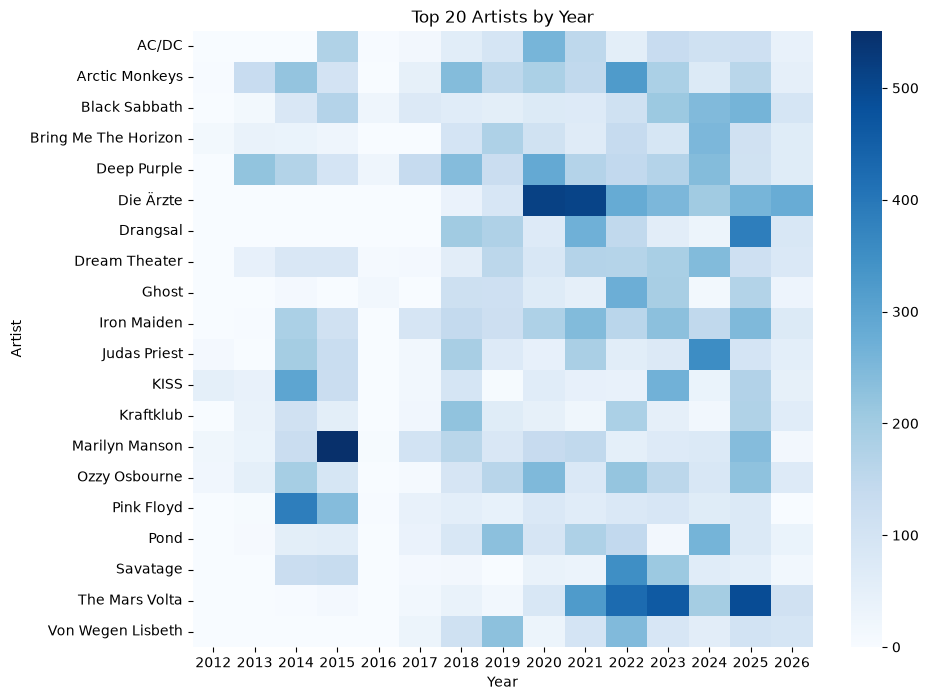

In [16]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data,
    annot=False,
    fmt="d",
    cmap="Blues"
)

plt.title("Top 20 Artists by Year")
plt.xlabel("Year")
plt.ylabel("Artist")

plt.show()

## Play time per weekday

In [17]:
df_music["weekday"] = df_music["ts"].dt.weekday
weekday_stats = (
    df_music
    .groupby(
        [
            "weekday"
        ]
    )
    .agg(
        play_count=("weekday", "count"),
        hours_played=("hours_played", "sum")
    )
    .reset_index()
)

In [18]:
weekday_stats["weekday_name"]=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

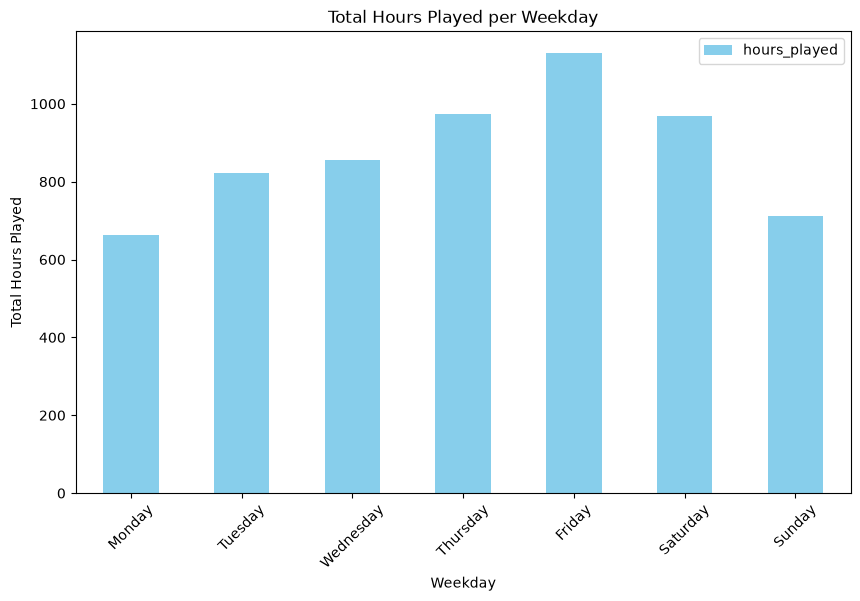

In [19]:
weekday_stats.plot(x="weekday_name", y="hours_played", kind="bar", figsize=(10, 6), color="skyblue")
plt.title("Total Hours Played per Weekday")
plt.xlabel("Weekday")
plt.ylabel("Total Hours Played")
plt.xticks(rotation=45)
plt.show()

## Play time per month

In [20]:
df_music["month"] = df_music["ts"].dt.month
month_stats = (
    df_music
    .groupby(
        [
            "month"
        ]
    )
    .agg(
        play_count=("month", "count"),
        hours_played=("hours_played", "sum")
    )
    .reset_index()
)

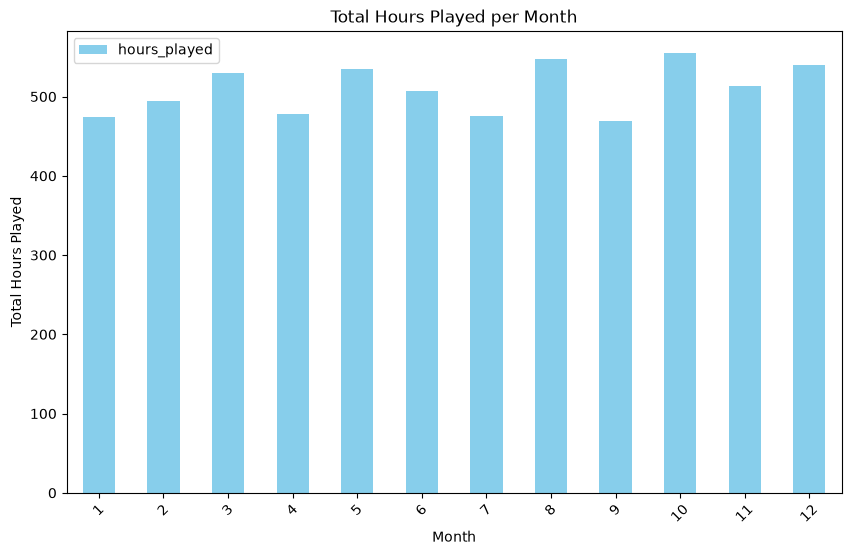

In [21]:
month_stats.plot(x="month", y="hours_played", kind="bar", figsize=(10, 6), color="skyblue")
plt.title("Total Hours Played per Month")
plt.xlabel("Month")
plt.ylabel("Total Hours Played")
plt.xticks(rotation=45)
plt.show()

## Saving dataframe with added features

In [22]:
df_music.to_pickle("../data/processed/df_music_features.pkl")